<a href="https://colab.research.google.com/github/navirath/ML-lab/blob/main/Copy_of_Logistic_Regression_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io

print("Please upload your file:")
uploaded = files.upload()

if not uploaded:
    print("No file was uploaded.")
else:
    for file_name, content_bytes in uploaded.items():
        print(f"\nProcessing uploaded file: '{file_name}'")
        try:
            # Decode the bytes content to a string, assuming UTF-8 encoding
            content_str = content_bytes.decode('utf-8')
            print(f"Content of '{file_name}':\n{content_str}")
        except Exception as e:
            print(f"An error occurred while reading or decoding '{file_name}': {e}")

Please upload your file:


Saving zoo-class-type.csv to zoo-class-type.csv

Processing uploaded file: 'zoo-class-type.csv'
Content of 'zoo-class-type.csv':
Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf, cavy, cheetah, deer, dolphin, elephant, fruitbat, giraffe, girl, goat, gorilla, hamster, hare, leopard, lion, lynx, mink, mole, mongoose, opossum, oryx, platypus, polecat, pony, porpoise, puma, pussycat, raccoon, reindeer, seal, sealion, squirrel, vampire, vole, wallaby, wolf"
2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, hawk, kiwi, lark, ostrich, parakeet, penguin, pheasant, rhea, skimmer, skua, sparrow, swan, vulture, wren"
3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, herring, pike, piranha, seahorse, sole, stingray, tuna"
5,4,Amphibian,"frog, frog, newt, toad"
6,8,Bug,"flea, gnat, honeybee, housefly, ladybird, moth, termite, wasp"
7,10,Invertebrat

Original DataFrame head:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  

Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


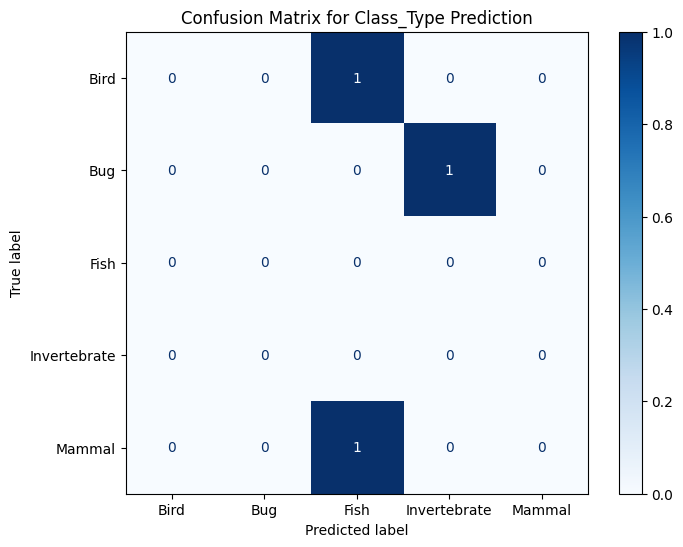

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import io
import numpy as np

# Assuming content_str contains the CSV data from the previous cell
if 'content_str' in locals() and content_str:
    df = pd.read_csv(io.StringIO(content_str))
    print("Original DataFrame head:")
    print(df.head())
    print("\nOriginal DataFrame info:")
    df.info()

    # Data Preprocessing
    # Drop 'Animal_Names' as it's a string and complex for direct use in this model
    df_processed = df.drop(columns=['Animal_Names'])

    # Encode 'Class_Type' into numerical labels
    label_encoder = LabelEncoder()
    df_processed['Class_Type_Encoded'] = label_encoder.fit_transform(df_processed['Class_Type'])

    # Define features (X) and target (y)
    X = df_processed[['Class_Number', 'Number_Of_Animal_Species_In_Class']]
    y = df_processed['Class_Type_Encoded']

    # Split data into training and testing sets
    # Removed 'stratify=y' because each class has only one member, which prevents stratification.
    # With a very small dataset like this (7 samples, 7 unique classes), a standard train-test split
    # might not be ideal for robust model evaluation or to accurately assess generalization.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    print(f"\nTraining data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")

    # Build Logistic Regression Model
    model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
    model.fit(X_train, y_train)

    print("\nLogistic Regression Model trained successfully.")

    # Measure the accuracy of the model
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nModel Accuracy: {accuracy:.4f}")

    # Plot the confusion matrix
    # Get all unique labels that appeared in either y_test or y_pred to ensure the confusion matrix can be plotted.
    # This addresses the ValueError when y_test contains no labels from model.classes_.
    all_observed_labels = np.unique(np.concatenate((y_test, y_pred)))

    cm = confusion_matrix(y_test, y_pred, labels=all_observed_labels)
    display_labels = label_encoder.inverse_transform(all_observed_labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title('Confusion Matrix for Class_Type Prediction')
    plt.show()

else:
    print("The 'content_str' variable was not found or was empty. Please make sure the file was uploaded and processed correctly in the previous cell.")
